<a href="https://colab.research.google.com/github/MEdan-US/Mini-Project/blob/hoang065/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Prelimaniries

## Import and Configuration

Sử dụng thư viện nào thì điền ở đây, không ghi dưới code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
# Mute warnings
warnings.filterwarnings('ignore')
print('Import Library Successfully')

Import Library Successfully


## Prepare dataset

In [ ]:
!gdown 1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh

Downloading...
From: https://drive.google.com/uc?id=1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh
To: /content/ai_student_impact_dataset.csv
100% 5.89M/5.89M [00:00<00:00, 26.2MB/s]


In [ ]:
DATA_PATH="/content/ai_student_impact_dataset.csv"
df=pd.read_csv(DATA_PATH,index_col="Student_ID")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       50

Biến Target là `Post_Semester GPA`

# Step 1: Exploratory Data Analysis

## Numerical Features (Mon)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu cụ thể (int64, float64).
  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) trên từng biến định lượng và đề xuất hướng xử lý (điền bằng mean, median hay xóa).
- Thống kê mô tả (Descriptive Statistics):
  - Tính toán các chỉ số cơ bản: Trung bình (Mean), Trung vị (Median), Độ lệch chuẩn (Std), Giá trị lớn nhất/nhỏ nhất (Min/Max), và các khoảng tứ phân vị (25%, 50%, 75%).
  - Vẽ biểu đồ phân phối (Histogram, KDE Plot) để xem dữ liệu có bị lệch (Skewed) hay tuân theo phân phối chuẩn không.
  - Phát hiện dữ liệu dị biệt (Outliers) bằng biểu đồ Boxplot hoặc phương pháp IQR / Z-score.
- Phân tích mức độ tương quan :
  - Vẽ ma trận tương quan (Correlation Matrix / Heatmap) giữa các biến định lượng với nhau để tìm ra hiện tượng đa cộng tuyến (Multicollinearity).
  - Vẽ Scatter Plot giữa các biến định lượng quan trọng để thấy xu hướng tuyến tính hoặc phi tuyến.

In [ ]:
numerical_data=df.select_dtypes(include=['int64', 'float64'])
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pre_Semester_GPA            50000 non-null  float64
 1   Weekly_GenAI_Hours          50000 non-null  float64
 2   Tool_Diversity              50000 non-null  int64  
 3   Traditional_Study_Hours     50000 non-null  float64
 4   Perceived_AI_Dependency     50000 non-null  int64  
 5   Anxiety_Level_During_Exams  50000 non-null  int64  
 6   Post_Semester_GPA           50000 non-null  float64
 7   Skill_Retention_Score       50000 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 3.4 MB


## Categorical Features (Thanh Hoàng)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu (object, category, bool).
  - Kiểm tra số lượng giá trị duy nhất (Cardinality - nunique). Lưu ý đặc biệt: Nếu một biến định tính có quá nhiều nhóm (ví dụ >50 nhóm), cần cảnh báo vì sẽ khó mã hóa sau này.

  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) và đề xuất hướng xử lý (điền bằng nhóm xuất hiện nhiều nhất - Mode, hoặc tạo một nhóm mới tên là "Unknown").

- Thống kê mô tả & Tần suất:
  - Lập bảng tần suất (Count) và tần suất phần trăm (Percentage) cho từng danh mục.
  - Trực quan hóa bằng biểu đồ cột (Bar chart) hoặc biểu đồ tròn (Pie chart - chỉ dùng khi có ít hơn 5 danh mục) để xem có sự mất cân bằng giữa các nhóm hay không.

- Mối tương quan:
  - Sử dụng Crosstab để xem tần suất kết hợp giữa các biến định tính quan trọng với nhau.

In [ ]:
categorical_data=df.select_dtypes(include=['object','bool'])
categorical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Major_Category            50000 non-null  object
 1   Year_of_Study             50000 non-null  object
 2   Primary_Use_Case          50000 non-null  object
 3   Prompt_Engineering_Skill  50000 non-null  object
 4   Paid_Subscription         50000 non-null  bool  
 5   Institutional_Policy      50000 non-null  object
 6   Burnout_Risk_Level        50000 non-null  object
dtypes: bool(1), object(6)
memory usage: 2.7+ MB


## Correlation Analysis (Minh Hoàng)

Yêu cầu:
- Kiểm tra dữ liệu:
  - Kiểm tra phân phối của biến mục tiêu. Nếu bị lệch quá nhiều (Skewed), cần đề xuất các phương pháp biến đổi (như Log Transformation) để chuẩn hóa dữ liệu.

- Phân tích Đa biến :
  - Dùng điểm tương hỗ MI (Mutual Information) để lọc ra các biến quan trọng với biến mục tiêu. Từ đó, xem xét các mối quan hệ xoay quanh những biến có điểm MI cao.
  - Biến mục tiêu và các biến định lượng: Vẽ biểu đồ Boxplot hoặc Violin Plot của biến định lượng theo từng nhóm của Target (nếu Target là định tính), hoặc vẽ Scatter Plot (nếu cả hai là định lượng) để xem biến định lượng nào tác động mạnh đến Target.

  - Biến mục tiêu và biến dịnh tính: Vẽ biểu đồ cột chồng hoặc biểu đồ tỉ lệ để xem tỷ lệ phân bố của Target thay đổi như thế nào trên từng danh mục.

In [ ]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


Original Skewness: -0.675
Square Transformation Skewness: -0.347
Cube Transformation Skewness: -0.090


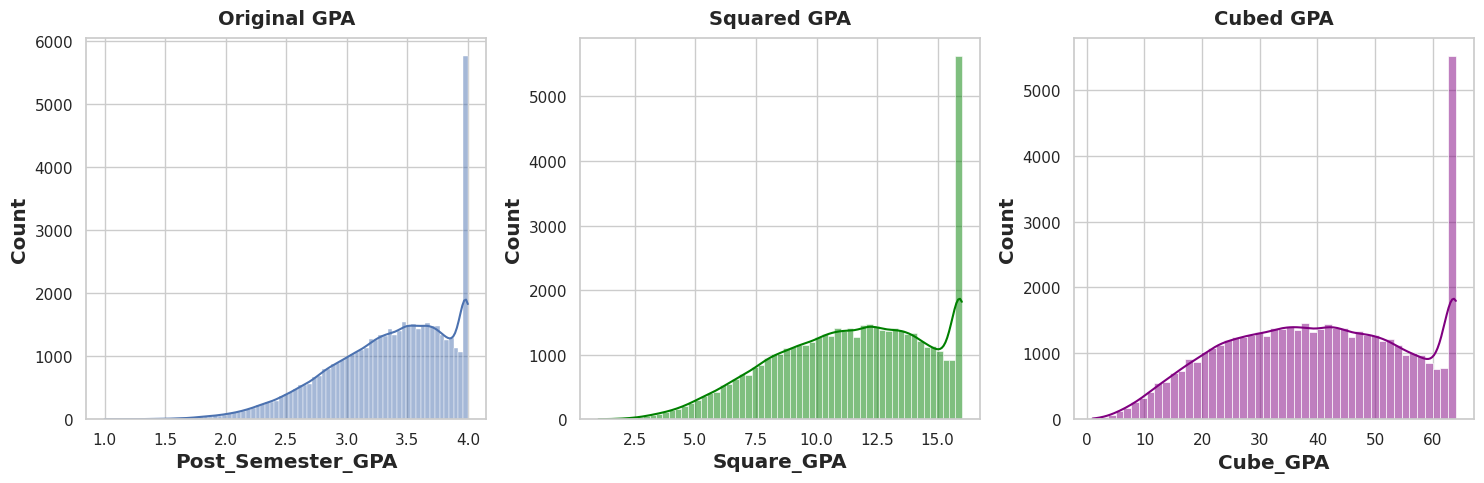

In [ ]:

target = 'Post_Semester_GPA'

# Phép biến đổi Bình phương (Square Transformation)
df['Square_GPA'] = df[target] ** 2

# Phép biến đổi Lập phương (Cube Transformation)
df['Cube_GPA'] = df[target] ** 3

# Kiểm tra lại độ lệch (Skewness)
print(f"Original Skewness: {df[target].skew():.3f}")
print(f"Square Transformation Skewness: {df['Square_GPA'].skew():.3f}")
print(f"Cube Transformation Skewness: {df['Cube_GPA'].skew():.3f}")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title('Original GPA')

sns.histplot(df['Square_GPA'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Squared GPA')

sns.histplot(df['Cube_GPA'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Cubed GPA')

plt.tight_layout()
plt.show()

# Đánh giá phân phối dữ liệu gốc:
### Độ lệch (Skewness): -0.675
### ->Biến Post_Semester_GPA bị lệch trái (Left-skewed / Negative Skewness) ở mức độ vừa phải.

## Không nên sử dụng Log Transformation vì biến GPA của chúng ta đang lệch trái, việc áp dụng phép biến đổi Log làm dữ liệu bị lệch nặng hơn (Skewness giảm xuống còn -0.99).

# Đề xuất các phương pháp chuẩn hóa phù hợp:
## Phép biến đổi lũy thừa (Square / Cube Transformation):
### Bình phương ($x^2$) hoặc lập phương ($x^3$) các giá trị GPA. Việc này sẽ kéo giãn sự khác biệt ở các giá trị lớn và thu hẹp sự khác biệt ở các giá trị nhỏ, giúp phân phối cân xứng hơn.=> đã làm minh họa ở trên
## Không biến đổi (Giữ nguyên dữ liệu gốc):
### Với mức skewness là -0.675, đây là mức độ lệch nằm trong ngưỡng cho phép.
### Nếu sử dụng các thuật toán dạng cây như Random Forest, XGBoost, LightGBM, không cần thiết phải chuẩn hóa biến mục tiêu vì các mô hình này không nhạy cảm với phân phối của dữ liệu.


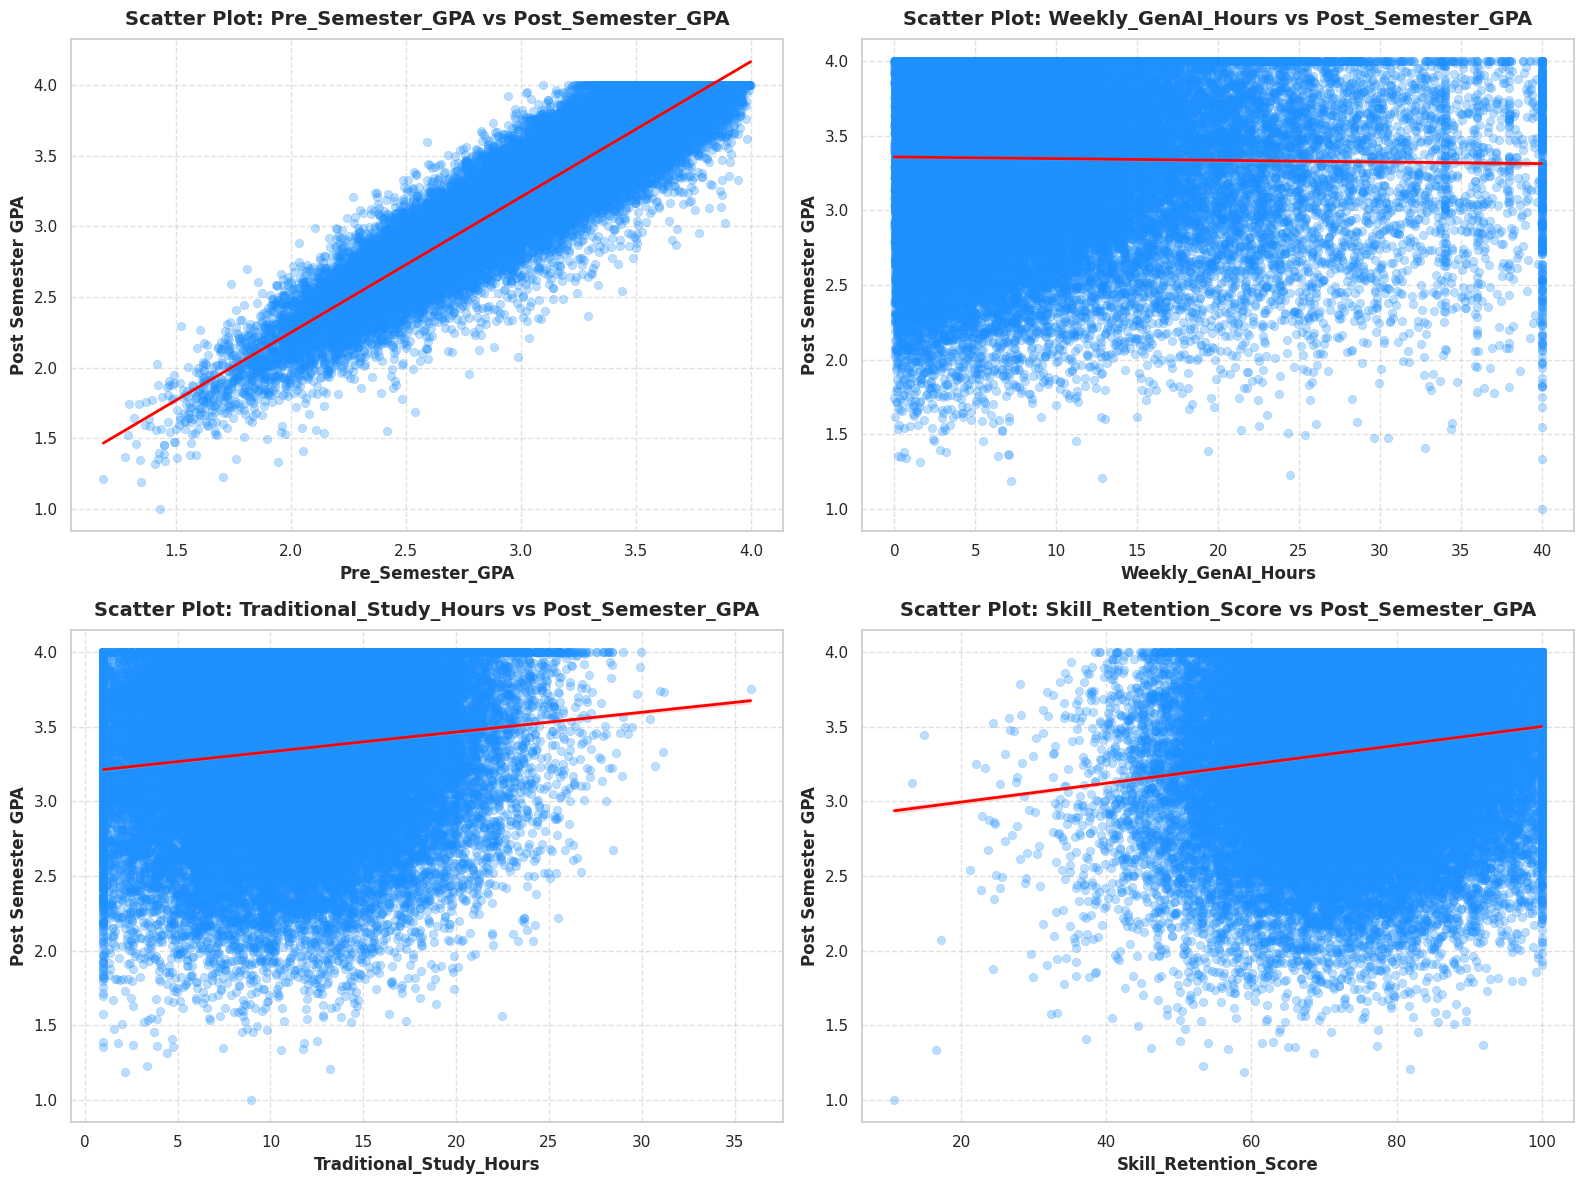

In [ ]:
quant_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        alpha=0.3,
        color='dodgerblue',
        edgecolor=None
    )

    sns.regplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        scatter=False,
        color='red',
        line_kws={"linewidth": 2}
    )

    axes[i].set_title(f'Scatter Plot: {col} vs {target}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Post Semester GPA', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Pre_Semester_GPA (Tương quan Tuyến tính Mạnh): Đường hồi quy màu đỏ có độ dốc lớn. Sự tương quan thuận là cực kỳ mạnh mẽ.
### Skill_Retention_Score (Tương quan Thuận Nhẹ): Đường xu hướng dốc lên một góc nhỏ. Có xu hướng những người có điểm duy trì kỹ năng cao hơn thì GPA cũng nhỉnh hơn.
### Traditional_Study_Hours (Tương quan Thuận Rất Nhẹ): Đường xu hướng gần như đi ngang nhưng vẫn có độ dốc dương rất nhỏ.
### Weekly_GenAI_Hours (Không có xu hướng rõ rệt): Đường xu hướng đi ngang hoàn toàn -> Thời lượng dùng AI hàng tuần hiện không cho thấy mối liên hệ trực tiếp với việc điểm số tăng hay giảm.

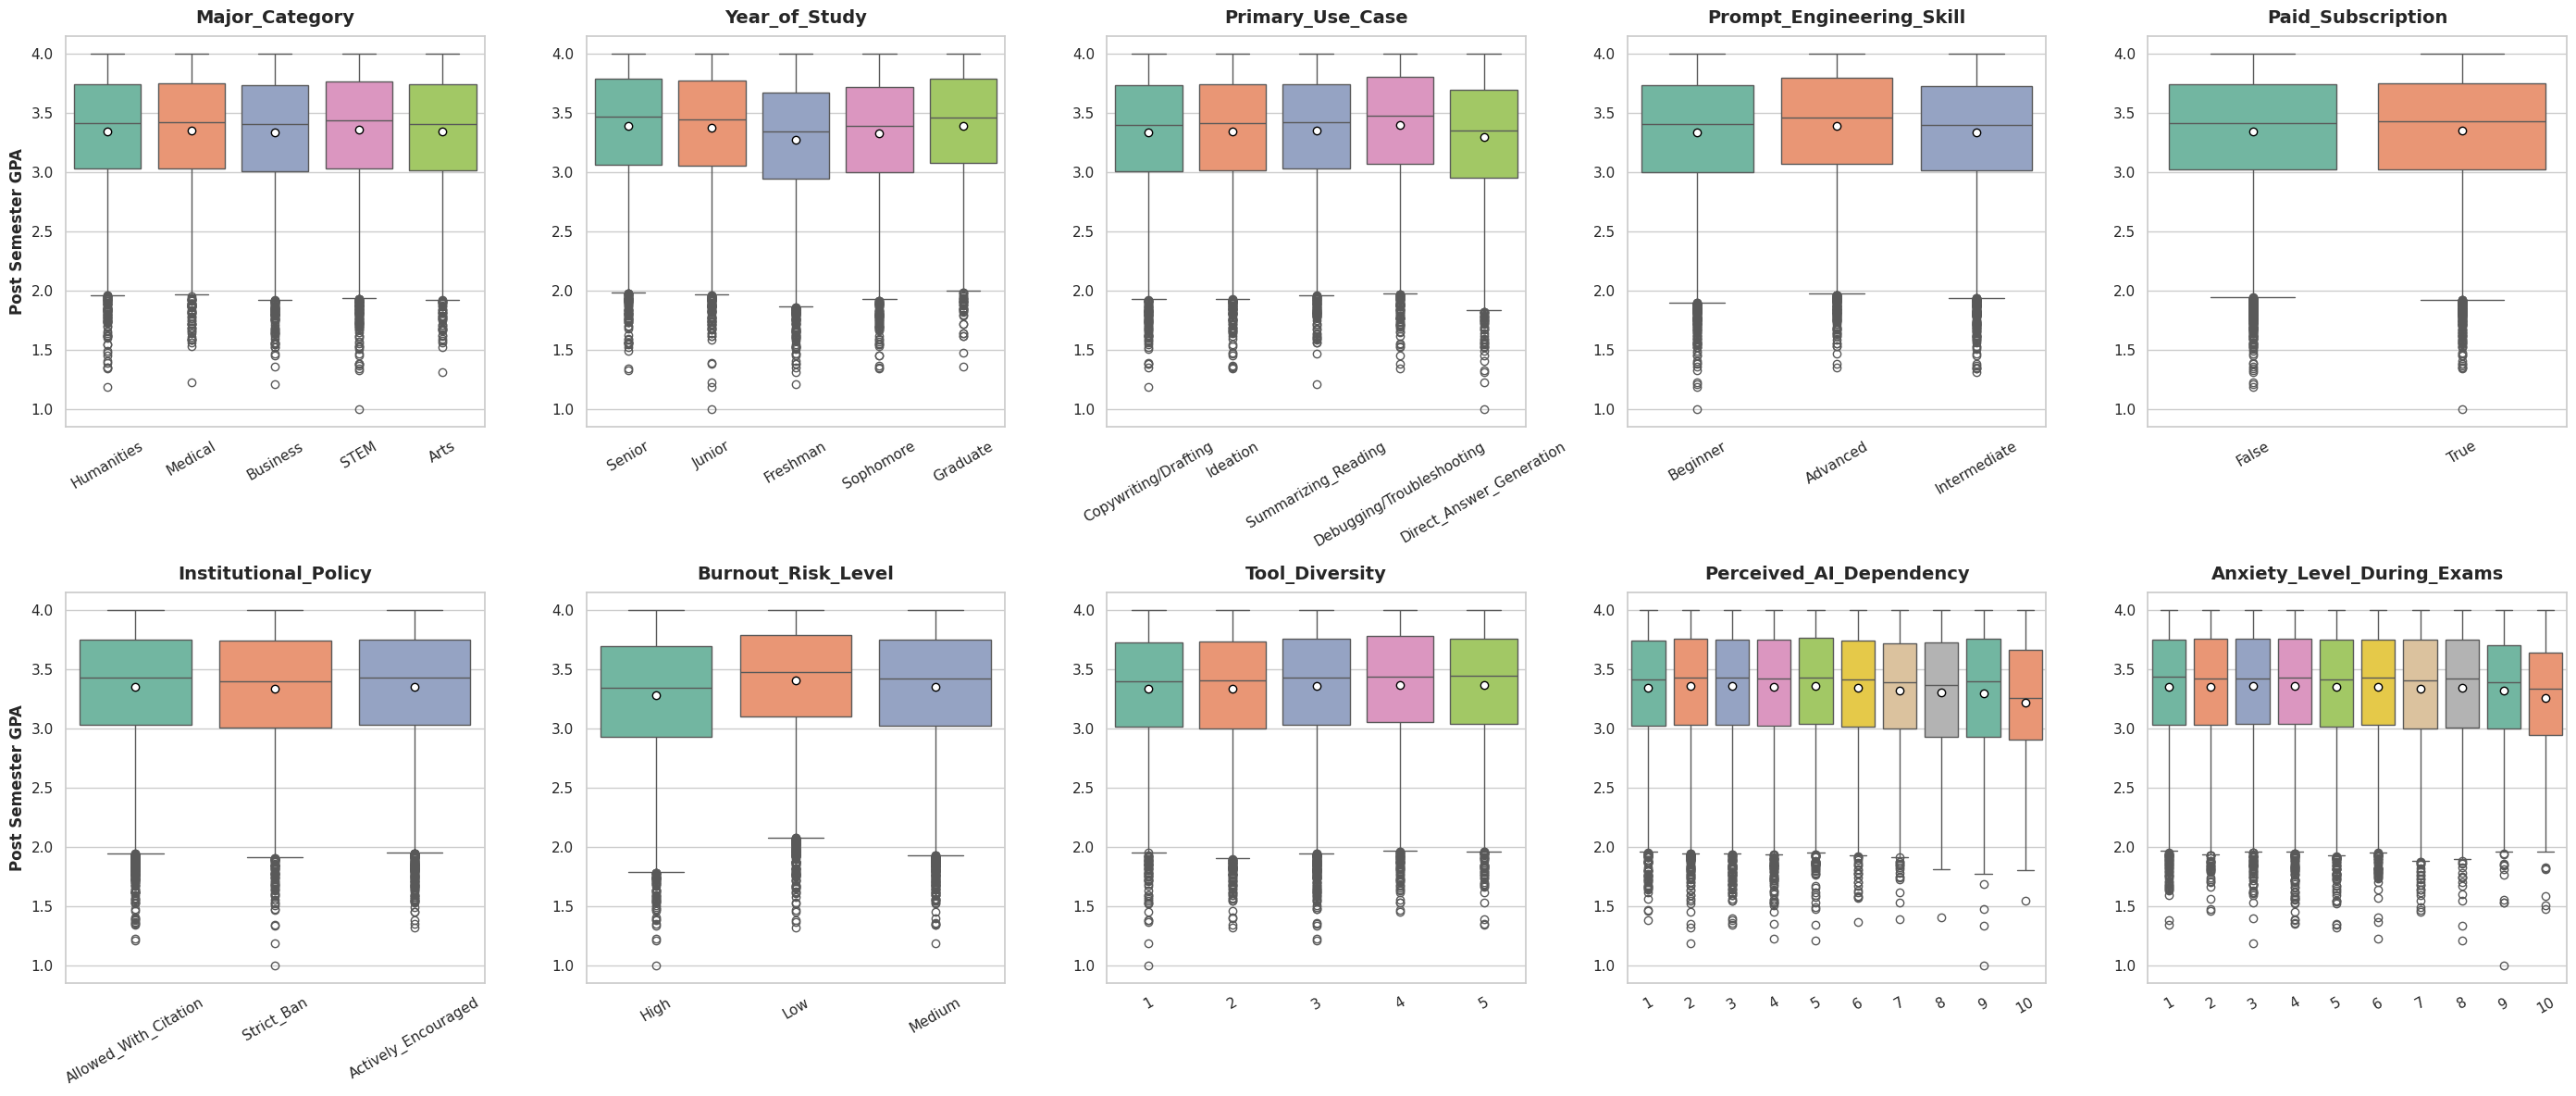

In [ ]:

# Tổng hợp tất cả biến định tính
# Bao gồm biến chữ/boolean
cat_cols_strict = df.select_dtypes(include=['object', 'bool']).columns.tolist()
# Và 3 biến số nguyên rời rạc
discrete_cols = ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
# Gom chung
all_qualitative_cols = cat_cols_strict + discrete_cols

# Tạo khung biểu đồ lưới 2 hàng x 5 cột (đủ cho 10 biến)
fig, axes = plt.subplots(2, 5, figsize=(28, 12))
axes = axes.flatten()

for i, col in enumerate(all_qualitative_cols):
    sns.boxplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        palette='Set2',
        showmeans=True, # Hiển thị thêm điểm Mean (trung bình)
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6}
    )

    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

    if i % 5 == 0:
        axes[i].set_ylabel('Post Semester GPA', fontsize=12)
    else:
        axes[i].set_ylabel('')

    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Sự phân bố của GPA cuối kỳ gần như ĐỒNG NHẤT ở tất cả các hạng mục của mọi biến định tính.
### Không có biến định tính nào tạo ra sự khác biệt rõ rệt về điểm số. Ví dụ, sinh viên dùng AI để "Copywriting/Drafting" (viết nháp) có phổ điểm hoàn toàn y hệt sinh viên dùng AI để "Debugging" (sửa lỗi code) hay "Ideation" (lên ý tưởng).
### Các điểm Trung bình (chấm trắng) và Trung vị (đường ngang trong hộp) của tất cả các nhóm trên cả 10 biểu đồ đều neo ở mức khoảng 3.0 - 3.2.

In [ ]:

# Dùng errors='ignore' để lệnh drop không báo lỗi nếu 'Student_ID' không tồn tại
X = df.drop(columns=['Student_ID', target, 'Square_GPA', 'Cube_GPA', 'Log_Post_Semester_GPA'], errors='ignore')
y = df[target]

#  Xử lý các biến rời rạc/định tính
discrete_cols = ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
all_discrete = discrete_cols + cat_cols

# Mã hóa (Label Encoding) cho biến chữ/boolean
X_encoded = X.copy()
le = LabelEncoder()
for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Tạo boolean mask (True/False)
discrete_features_mask = X_encoded.columns.isin(all_discrete)

# 3. Tính điểm MI
mi_scores = mutual_info_regression(
    X_encoded, y,
    discrete_features=discrete_features_mask,
    random_state=42
)
mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

print("TOP CÁC BIẾN QUAN TRỌNG NHẤT (MI SCORES):")
print(mi_series.head())

TOP CÁC BIẾN QUAN TRỌNG NHẤT (MI SCORES):
Pre_Semester_GPA           0.937000
Skill_Retention_Score      0.016435
Traditional_Study_Hours    0.011274
Year_of_Study              0.006637
Burnout_Risk_Level         0.004581
dtype: float64


### Pre_Semester_GPA (MI = 0.937) - Tương quan tuyến tính tuyệt đối: Sinh viên có điểm khởi đầu (đầu kỳ) thế nào thì cuối kỳ gần như giữ nguyên phong độ đó.-> AI chỉ mang tính hỗ trợ
### Cách sinh viên dung nạp kiến thức (Skill_Retention_Score và Traditional_Study_Hours) quan trọng hơn rất nhiều so với thời lượng tương tác với AI (Weekly_GenAI_Hours - vốn có điểm MI bét bảng).
### Sự nhiễu của các biến công nghệ: Hầu hết các biến liên quan đến AI (Số công cụ, Trả phí hay miễn phí, Kỹ năng Prompt) đều không có mối quan hệ trực tiếp đủ mạnh để quyết định điểm GPA cuối kỳ.

# Step 2: Data Preprocessing

Yêu cầu:
- clean: xử lý dữ liệu bị khuyết, trùng lặp, sửa lỗi định dạng và kiểu dữ liệu
- encode: mã hóa các biến phân loại
- impute: điền vào các giá trị NaN

In [ ]:
def load_data():
    # Read data
    data_dir = "/content/ai_student_impact_dataset.csv"
    df = pd.read_csv(data_dir, index_col="Student_Id")
    # Preprocessing
    df = clean(df)
    df = encode(df)
    df = impute(df)

    # Reform splits
    df = df.loc[df.index, :]
    return df

### Clean data

In [ ]:
def clean(df):
  ''' Hàm làm sạch dữ liệu'''
  return df


### Impute data

In [ ]:
def impute(df):
  ''' Hàm thêm các giá trị khuyết'''
  return df

### Encode data

In [ ]:
def encode(df):
  ''' Hàm mã hóa dữ liệu'''
  return df


# Step 3: Feature Engineering

# Step 4: Modelling